# HỆ THỐNG GỢI Ý PHÂN KHÚC KHÁCH HÀNG F&B & TOURISM TẠI TP.HCM

### 📌 Phiên bản improved_v3 — 3 cải tiến thực nghiệm bổ sung

Giữ nguyên pipeline gốc: Zero-shot weak labeling bằng `joeddav/xlm-roberta-large-xnli`,
taxonomy, preprocessing, MultilabelStratified split, RF baseline, CV, gold-label validation.

**3 cải tiến thực nghiệm mới:**

1. **Classifier thay thế cho SBERT/concat** — Logistic Regression + Linear SVM song song với RF.

2. **TruncatedSVD giảm chiều TF-IDF** — 5.000 → 300 trước khi concat với SBERT (768) → 1.068.

3. **SBERT Multilingual baseline** — `paraphrase-multilingual-mpnet-base-v2` + RF, biến thiên duy nhất là embedding model.

| Nhánh | Embedding | Classifier |
|---|---|---|
| TF-IDF + RF | TF-IDF (5k) | RF |
| SBERT-VN + RF | bkai-foundation-models/vietnamese-bi-encoder | RF |
| SBERT-VN + LR | bkai-foundation-models/vietnamese-bi-encoder | LR |
| SBERT-VN + SVM | bkai-foundation-models/vietnamese-bi-encoder | LinearSVC |
| SVD-concat + RF | SVD(300)+SBERT (1068) | RF |
| SVD-concat + LR | SVD(300)+SBERT (1068) | LR |
| Raw-concat + RF | TF-IDF(5k)+SBERT (5768) | RF |
| SBERT-ML + RF | mpnet-multilingual (768) | RF |

In [1]:
!pip install -q datasets transformers scikit-learn torch sentence-transformers pandas numpy matplotlib seaborn scipy iterative-stratification



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\DUNG\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import warnings
warnings.filterwarnings('ignore')

from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.multioutput import MultiOutputClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score, precision_score, recall_score, cohen_kappa_score
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from transformers import pipeline
from scipy.stats import wilcoxon

from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit, MultilabelStratifiedKFold

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DEVICE = 0 if torch.cuda.is_available() else -1
device_name = 'GPU' if DEVICE == 0 else 'CPU'
print(f"Import thanh cong | Thiet bi: {device_name}")


Import thanh cong | Thiet bi: CPU


## 1. Load & Lọc Dataset (TP.HCM)

In [3]:
dataset = load_dataset("nvidia/Nemotron-Personas-Vietnam", split="train")
df = dataset.to_pandas()

df_hcm = df[df['region'] == 'Thành Phố Hồ Chí Minh'].copy()
df_hcm = df_hcm.reset_index(drop=True)

print(f"So records TP.HCM: {len(df_hcm):,}")


So records TP.HCM: 34,733


## 2. Lấy mẫu N=10.000 (giống bản gốc)

In [4]:
SAMPLE_SIZE = 10000

if len(df_hcm) > SAMPLE_SIZE:
    df_sample = df_hcm.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE).reset_index(drop=True)
else:
    df_sample = df_hcm.reset_index(drop=True)

print(f"Kich thuoc tap thuc nghiem: {len(df_sample):,} persona")


Kich thuoc tap thuc nghiem: 10,000 persona


## 3. Hợp nhất Văn bản Persona

In [5]:
def merge_text(row):
    fields = ['persona', 'professional_persona', 'culinary_persona', 'travel_persona',
              'hobbies_and_interests', 'cultural_background']
    parts = [str(row.get(f, '')) for f in fields if pd.notna(row.get(f)) and str(row.get(f)).strip()]
    return ' '.join(parts)

df_sample['merged_text'] = df_sample.apply(merge_text, axis=1)
print('Da hop nhat van ban')
print(f"Do dai trung binh: {df_sample['merged_text'].str.len().mean():.0f} ky tu")


Da hop nhat van ban
Do dai trung binh: 1273 ky tu


## 4. Taxonomy Ngành hàng F&B & Tourism

In [6]:
taxonomy = {
    'fnb_street':    'thích ăn uống vỉa hè bình dân, món ăn đường phố giá rẻ',
    'fnb_fine':      'thích nhà hàng sang trọng, ẩm thực cao cấp, trải nghiệm fine-dining đắt tiền',
    'fnb_cafe':      'thích ngồi quán cà phê, không gian yên tĩnh để làm việc hoặc trò chuyện',
    'fnb_healthy':   'quan tâm ăn uống lành mạnh, ăn chay, thực phẩm hữu cơ, giữ vóc dáng',
    'tour_cultural': 'thích tham quan di tích lịch sử, đền chùa, bảo tàng, giá trị văn hóa truyền thống',
    'tour_resort':   'thích nghỉ dưỡng cao cấp, resort biển, spa thư giãn, du lịch sang trọng',
    'tour_adventure':'thích phượt, leo núi, khám phá thiên nhiên hoang dã, du lịch mạo hiểm',
    'tour_food':     'thích đi du lịch chỉ để khám phá và thưởng thức món ăn đặc sản địa phương',
    'tour_festival': 'thích tham gia lễ hội, sự kiện âm nhạc, hoạt động cộng đồng đông người',
}

labels = list(taxonomy.keys())
candidate_label_texts = list(taxonomy.values())

VI_HYPOTHESIS_TEMPLATE = "Người này {}."

print('Taxonomy gom', len(labels), 'phan khuc (co dau day du)')


Taxonomy gom 9 phan khuc (co dau day du)


## 5. Weak Labeling bằng Zero-shot LLM — `joeddav/xlm-roberta-large-xnli`

Ngưỡng thích ứng theo nhãn + hypothesis_template tiếng Việt có dấu.

In [7]:
zero_shot_classifier = pipeline(
    "zero-shot-classification",
    model="joeddav/xlm-roberta-large-xnli",
    device=DEVICE
)
print(f"Da nap model zero-shot: joeddav/xlm-roberta-large-xnli")
print(f"Hypothesis template: {VI_HYPOTHESIS_TEMPLATE}")


Some weights of the model checkpoint at joeddav/xlm-roberta-large-xnli were not used when initializing XLMRobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing XLMRobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing XLMRobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


Da nap model zero-shot: joeddav/xlm-roberta-large-xnli
Hypothesis template: Người này {}.


In [8]:
def weak_label_batch(texts, candidate_labels, batch_size=16, max_chars=512):
    truncated = [t[:max_chars] for t in texts]
    all_scores = []
    for i in range(0, len(truncated), batch_size):
        batch = truncated[i:i + batch_size]
        results = zero_shot_classifier(
            batch, candidate_labels,
            multi_label=True,
            hypothesis_template=VI_HYPOTHESIS_TEMPLATE
        )
        if isinstance(results, dict):
            results = [results]
        for res in results:
            score_map = dict(zip(res['labels'], res['scores']))
            all_scores.append([score_map[lb_text] for lb_text in candidate_labels])
        if (i // batch_size) % 10 == 0:
            print(f"  Xu ly {min(i + batch_size, len(truncated))}/{len(truncated)}...", end='\r')
    return np.array(all_scores)


def compute_adaptive_thresholds(scores, target_rate=0.25):
    thresholds = np.zeros(scores.shape[1])
    for j in range(scores.shape[1]):
        thresholds[j] = np.percentile(scores[:, j], 100 * (1 - target_rate))
    return thresholds


def binarize_labels_adaptive(scores, thresholds, max_labels=3):
    binary = np.zeros_like(scores, dtype=int)
    for i in range(len(scores)):
        candidates = np.where(scores[i] >= thresholds)[0]
        if len(candidates) == 0:
            candidates = np.array([np.argmax(scores[i])])
        if len(candidates) > max_labels:
            top = candidates[np.argsort(scores[i][candidates])[::-1][:max_labels]]
            binary[i, top] = 1
        else:
            binary[i, candidates] = 1
    return binary


TARGET_POSITIVE_RATE = 0.25
MAX_LABELS = 3

print("Bat dau zero-shot weak labeling...")
y_scores_zs = weak_label_batch(df_sample['merged_text'].tolist(), candidate_label_texts)

adaptive_thresholds = compute_adaptive_thresholds(y_scores_zs, target_rate=TARGET_POSITIVE_RATE)
y_binary = binarize_labels_adaptive(y_scores_zs, adaptive_thresholds, max_labels=MAX_LABELS)

for i, label in enumerate(labels):
    df_sample[label] = y_binary[:, i]
    df_sample[f"{label}_score"] = y_scores_zs[:, i]

print(f"\nWeak labeling hoan tat | Nhan TB/persona: {y_binary.sum(axis=1).mean():.2f}")


Bat dau zero-shot weak labeling...
  Xu ly 9936/10000...
Weak labeling hoan tat | Nhan TB/persona: 1.89


## 6. Kiểm soát chất lượng nhãn yếu (QC)

In [9]:
qc_sample = df_sample.sample(n=min(15, len(df_sample)), random_state=RANDOM_STATE)
print("=== MAU KIEM TRA THU CONG (QC) ===")
for idx, row in qc_sample.iterrows():
    assigned = [l for l in labels if row[l] == 1]
    print(f"\n--- Persona #{idx} ---")
    print("Van ban (rut gon):", row['merged_text'][:200], "...")
    print("Nhan duoc gan:", assigned if assigned else "(khong nhan nao vuot nguong)")


=== MAU KIEM TRA THU CONG (QC) ===

--- Persona #6252 ---
Van ban (rut gon): Nguyễn Thị Lan, 26 tuổi, đang sống trong một căn hộ tập thể tại khu Phường 8, Bình Thạnh. Cô là một phụ nữ trẻ với sự tò mò về nghệ thuật và truyền thống, luôn tìm cách kết nối với cộng đồng qua các h ...
Nhan duoc gan: ['tour_festival']

--- Persona #4684 ---
Van ban (rut gon): Lê Đức Tuấn, một chàng trai 29 tuổi làm trong ngành y tế tại Sài Gòn. Anh có niềm đam mê nghệ thuật và thích khám phá các món ăn mới. Anh cũng là người năng động, yêu thể thao và thích tham gia các lễ ...
Nhan duoc gan: ['tour_cultural', 'tour_food', 'tour_festival']

--- Persona #1731 ---
Van ban (rut gon): Anh Lê Quốc Hải là một người đàn ông trưởng thành, 39 tuổi, sinh ra và lớn lên trong một căn nhà tập thể ở Sài Gòn. Anh yêu thích sự cân bằng giữa truyền thống và hiện đại, đặc biệt là trong việc kết  ...
Nhan duoc gan: ['fnb_street', 'fnb_fine', 'tour_resort']

--- Persona #4742 ---
Van ban (rut gon): Anh Nguyễn Đức Tuấn, 22 tuổi,

## 7. Thống kê & EDA

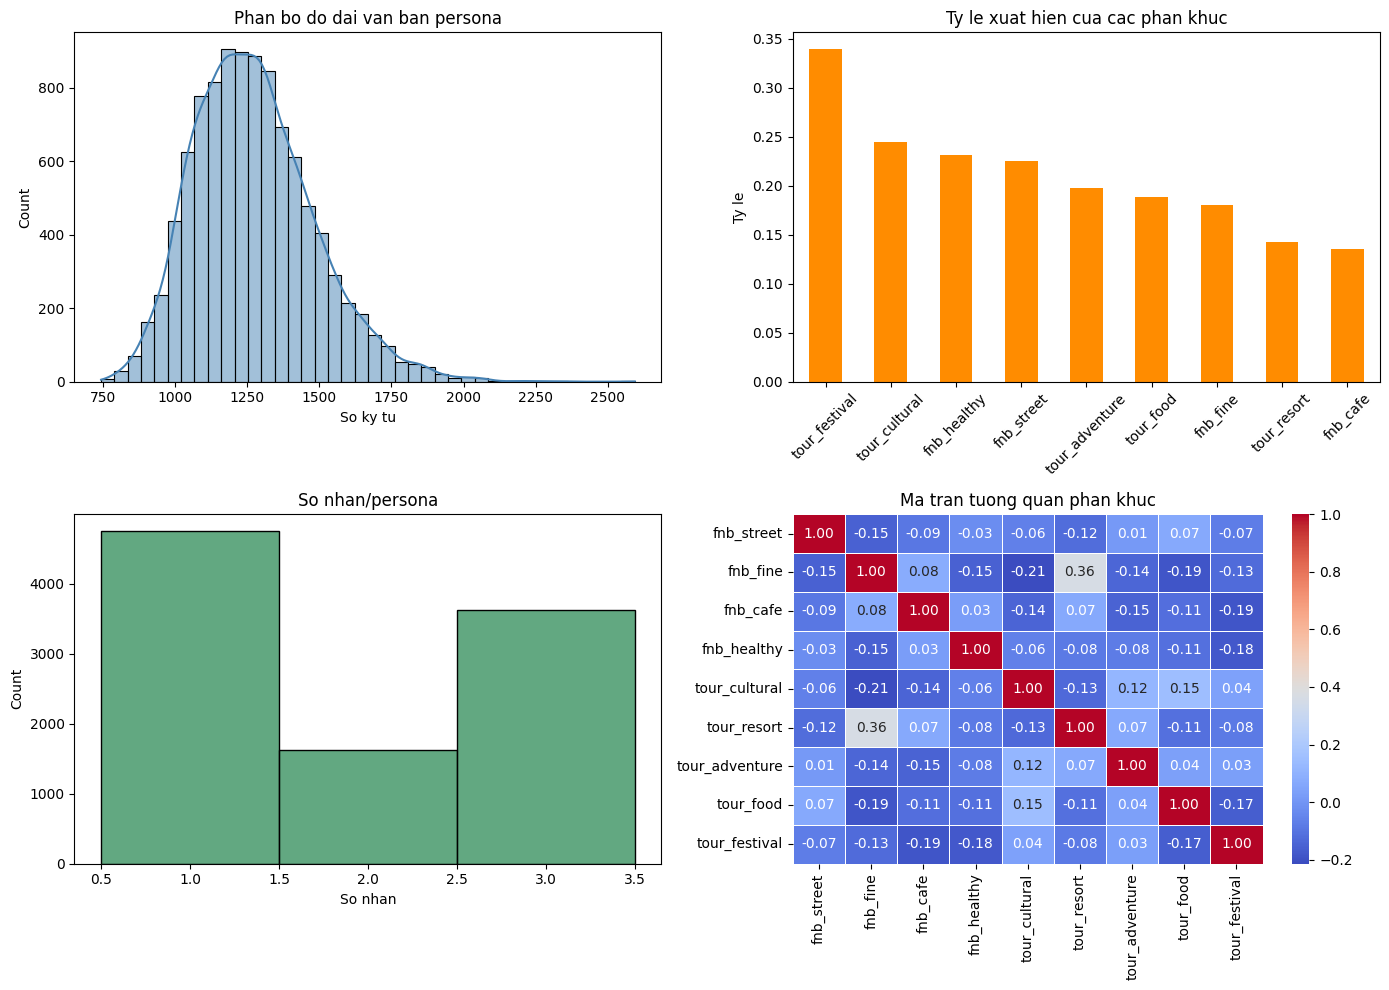

Da luu eda_summary_improved_v3.png


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df_sample['merged_text'].str.len(), bins=40, kde=True, color='steelblue', ax=axes[0, 0])
axes[0, 0].set_title('Phan bo do dai van ban persona')
axes[0, 0].set_xlabel('So ky tu')

label_prevalence = df_sample[labels].mean().sort_values(ascending=False)
label_prevalence.plot(kind='bar', color='darkorange', ax=axes[0, 1])
axes[0, 1].set_title('Ty le xuat hien cua cac phan khuc')
axes[0, 1].set_ylabel('Ty le')
axes[0, 1].tick_params(axis='x', rotation=45)

n_labels_per_sample = df_sample[labels].sum(axis=1)
sns.histplot(n_labels_per_sample, bins=range(0, MAX_LABELS + 3),
             discrete=True, color='seagreen', ax=axes[1, 0])
axes[1, 0].set_title('So nhan/persona')
axes[1, 0].set_xlabel('So nhan')

corr = df_sample[labels].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1, 1], linewidths=0.5)
axes[1, 1].set_title('Ma tran tuong quan phan khuc')

plt.tight_layout()
plt.savefig('eda_summary_improved_v3.png', dpi=120)
plt.show()
print('Da luu eda_summary_improved_v3.png')


## 8. Trích xuất Đặc trưng — TF-IDF, SBERT-VN, SVD-concat, Raw-concat, SBERT-ML

**CẢI TIẾN (2):** TruncatedSVD giảm TF-IDF 5000 → 300 trước khi concat với SBERT → 1068 chiều.

**CẢI TIẾN (3):** SBERT Multilingual (`paraphrase-multilingual-mpnet-base-v2`) làm baseline đối chứng.

In [11]:
texts = df_sample['merged_text'].tolist()

# --- TF-IDF (5000 chieu, ngram_range=(1,2), min_df=2) ---
print("Dang tinh TF-IDF...")
tfidf_vec = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)
X_tfidf = tfidf_vec.fit_transform(texts)
print(f"TF-IDF shape: {X_tfidf.shape}")

# --- TruncatedSVD: TF-IDF 5000 -> 300 (CAI TIEN 2) ---
print("Dang giam chieu TF-IDF bang TruncatedSVD (5000 -> 300)...")
SVD_N_COMPONENTS = 300
svd = TruncatedSVD(n_components=SVD_N_COMPONENTS, random_state=RANDOM_STATE)
norm_svd = Normalizer(copy=False)
X_tfidf_svd = norm_svd.fit_transform(svd.fit_transform(X_tfidf))
print(f"SVD-TF-IDF shape: {X_tfidf_svd.shape} | Phuong sai giai thich: {svd.explained_variance_ratio_.sum():.3f}")

# --- SBERT-VN: bkai-foundation-models/vietnamese-bi-encoder ---
print("\nDang encode SBERT tieng Viet (bkai-foundation-models/vietnamese-bi-encoder)...")
sbert_vn = SentenceTransformer('bkai-foundation-models/vietnamese-bi-encoder')
X_sbert_vn = sbert_vn.encode(texts, batch_size=64, show_progress_bar=True, convert_to_numpy=True)
print(f"SBERT-VN shape: {X_sbert_vn.shape}")

# --- SVD-concat: SVD-TF-IDF (300) + SBERT-VN (768) = 1068 chieu (CAI TIEN 2) ---
X_svd_concat = np.hstack([X_tfidf_svd, X_sbert_vn])
print(f"SVD-concat shape: {X_svd_concat.shape}")

# --- Raw-concat: TF-IDF dense (5000) + SBERT-VN (768) = 5768 chieu (baseline tu ban goc) ---
X_tfidf_dense = X_tfidf.toarray()
X_raw_concat = np.hstack([X_tfidf_dense, X_sbert_vn])
print(f"Raw-concat shape: {X_raw_concat.shape}")

# --- SBERT-ML: paraphrase-multilingual-mpnet-base-v2 (CAI TIEN 3) ---
print("\nDang encode SBERT Multilingual (paraphrase-multilingual-mpnet-base-v2)...")
sbert_ml = SentenceTransformer('paraphrase-multilingual-mpnet-base-v2')
X_sbert_ml = sbert_ml.encode(texts, batch_size=64, show_progress_bar=True, convert_to_numpy=True)
print(f"SBERT-ML shape: {X_sbert_ml.shape}")

print("\n=== Tom tat dac trung ===")
print(f"TF-IDF (sparse):     {X_tfidf.shape}")
print(f"SVD-TF-IDF (dense):  {X_tfidf_svd.shape}")
print(f"SBERT-VN (dense):    {X_sbert_vn.shape}")
print(f"SVD-concat (1068):   {X_svd_concat.shape}")
print(f"Raw-concat (5768):   {X_raw_concat.shape}")
print(f"SBERT-ML (dense):    {X_sbert_ml.shape}")


Dang tinh TF-IDF...
TF-IDF shape: (10000, 5000)
Dang giam chieu TF-IDF bang TruncatedSVD (5000 -> 300)...
SVD-TF-IDF shape: (10000, 300) | Phuong sai giai thich: 0.527

Dang encode SBERT tieng Viet (bkai-foundation-models/vietnamese-bi-encoder)...


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

SBERT-VN shape: (10000, 768)
SVD-concat shape: (10000, 1068)
Raw-concat shape: (10000, 5768)

Dang encode SBERT Multilingual (paraphrase-multilingual-mpnet-base-v2)...


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

SBERT-ML shape: (10000, 768)

=== Tom tat dac trung ===
TF-IDF (sparse):     (10000, 5000)
SVD-TF-IDF (dense):  (10000, 300)
SBERT-VN (dense):    (10000, 768)
SVD-concat (1068):   (10000, 1068)
Raw-concat (5768):   (10000, 5768)
SBERT-ML (dense):    (10000, 768)


## 9. Hàm đánh giá Ranking (Precision@K, Recall@K, NDCG@K)

In [12]:
def precision_recall_at_k(y_true, y_score, k):
    precisions, recalls = [], []
    for i in range(len(y_true)):
        top_k_idx = np.argsort(y_score[i])[::-1][:k]
        relevant_in_topk = y_true[i][top_k_idx].sum()
        precisions.append(relevant_in_topk / k)
        total_relevant = y_true[i].sum()
        recalls.append(relevant_in_topk / total_relevant if total_relevant > 0 else 0.0)
    return float(np.mean(precisions)), float(np.mean(recalls))


def ndcg_at_k_batch(y_true, y_score, k):
    def dcg(relevances):
        return sum(rel / np.log2(i + 2) for i, rel in enumerate(relevances))
    ndcgs = []
    for i in range(len(y_true)):
        top_k = np.argsort(y_score[i])[::-1][:k]
        rel_at_k = y_true[i][top_k].tolist()
        ideal_rel = sorted(y_true[i].tolist(), reverse=True)[:k]
        ideal_dcg = dcg(ideal_rel)
        ndcgs.append(dcg(rel_at_k) / ideal_dcg if ideal_dcg > 0 else 0.0)
    return float(np.mean(ndcgs))

print("Da dinh nghia ham danh gia ranking.")


Da dinh nghia ham danh gia ranking.


## 10. Majority Baseline

In [13]:
def majority_baseline_predict(y_train, n_test, k=None):
    if k is None:
        k = max(1, round(y_train.sum(axis=1).mean()))
    rates = y_train.mean(axis=0)
    top_k_idx = np.argsort(rates)[::-1][:k]
    pred = np.zeros((n_test, y_train.shape[1]), dtype=int)
    pred[:, top_k_idx] = 1
    return pred, rates, k

print('Da dinh nghia majority_baseline_predict.')


Da dinh nghia majority_baseline_predict.


## 11. Multilabel Stratified Split + Helper Classifier

**CẢI TIẾN (1):** `make_classifier` hỗ trợ RF / LR / SVM.
`fit_predict_tuned` train + tuned threshold predict.

In [14]:
y = y_binary.copy()
n_total = len(y)

msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
idx_train, idx_test = next(msss.split(np.zeros(n_total), y))

y_train, y_test = y[idx_train], y[idx_test]

X_tfidf_tr        = X_tfidf[idx_train]
X_tfidf_te        = X_tfidf[idx_test]
X_svd_tr          = X_tfidf_svd[idx_train]
X_svd_te          = X_tfidf_svd[idx_test]
X_sbert_vn_tr     = X_sbert_vn[idx_train]
X_sbert_vn_te     = X_sbert_vn[idx_test]
X_svd_concat_tr   = X_svd_concat[idx_train]
X_svd_concat_te   = X_svd_concat[idx_test]
X_raw_concat_tr   = X_raw_concat[idx_train]
X_raw_concat_te   = X_raw_concat[idx_test]
X_sbert_ml_tr     = X_sbert_ml[idx_train]
X_sbert_ml_te     = X_sbert_ml[idx_test]

print(f"Train: {len(idx_train):,} | Test: {len(idx_test):,}")
print(f"Nhan TB/persona (train): {y_train.sum(axis=1).mean():.2f}")
print(f"Nhan TB/persona (test):  {y_test.sum(axis=1).mean():.2f}")


Train: 7,991 | Test: 2,009
Nhan TB/persona (train): 1.89
Nhan TB/persona (test):  1.88


In [15]:
RF_PARAMS = dict(n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)


def make_classifier(clf_type, random_state=RANDOM_STATE):
    """clf_type: 'RF' | 'LR' | 'SVM'"""
    if clf_type == 'RF':
        base = RandomForestClassifier(**RF_PARAMS)
    elif clf_type == 'LR':
        base = LogisticRegression(
            C=1.0, solver='saga', max_iter=2000,
            class_weight='balanced', random_state=random_state, n_jobs=-1
        )
    elif clf_type == 'SVM':
        base = LinearSVC(
            C=1.0, class_weight='balanced',
            max_iter=2000, random_state=random_state
        )
    else:
        raise ValueError(f"clf_type khong hop le: {clf_type}")
    return MultiOutputClassifier(base, n_jobs=1)


def fit_predict_tuned(X_tr, y_tr, X_te, clf_type='RF', target_rate=0.25):
    """Train + predict with per-label tuned threshold."""
    clf = make_classifier(clf_type)
    clf.fit(X_tr, y_tr)

    if clf_type == 'SVM':
        raw = np.column_stack([est.decision_function(X_te) for est in clf.estimators_])
        raw_tr = np.column_stack([est.decision_function(X_tr) for est in clf.estimators_])
        mn, mx = raw_tr.min(axis=0), raw_tr.max(axis=0)
        denom = np.where(mx - mn == 0, 1, mx - mn)
        y_score = np.clip((raw - mn) / denom, 0, 1)
    else:
        y_score = np.column_stack([est.predict_proba(X_te)[:, 1] for est in clf.estimators_])

    thresholds = np.array([
        np.percentile(y_score[:, j], 100 * (1 - target_rate))
        for j in range(y_score.shape[1])
    ])
    y_pred = binarize_labels_adaptive(y_score, thresholds, max_labels=MAX_LABELS)
    return y_pred, y_score, thresholds, clf


print("Da dinh nghia make_classifier va fit_predict_tuned (RF / LR / SVM).")


Da dinh nghia make_classifier va fit_predict_tuned (RF / LR / SVM).


## 12. Đánh giá Holdout — Tất cả nhánh mô hình

9 nhánh song song (Majority + 8 model).

In [16]:
majority_pred, majority_rates, _ = majority_baseline_predict(y_train, len(y_test))
majority_score = np.tile(majority_rates, (len(y_test), 1))
f1_micro_baseline = f1_score(y_test, majority_pred, average='micro', zero_division=0)
f1_macro_baseline = f1_score(y_test, majority_pred, average='macro', zero_division=0)
print(f"Majority Baseline -> Micro F1: {f1_micro_baseline:.4f} | Macro F1: {f1_macro_baseline:.4f}")


Majority Baseline -> Micro F1: 0.3003 | Macro F1: 0.0998


In [17]:
print("Dang huan luyen TF-IDF + RF...")
y_pred_tfidf_rf, y_score_tfidf_rf, _, _ = fit_predict_tuned(X_tfidf_tr, y_train, X_tfidf_te, clf_type='RF')
f1_mi_tfidf_rf = f1_score(y_test, y_pred_tfidf_rf, average='micro', zero_division=0)
f1_ma_tfidf_rf = f1_score(y_test, y_pred_tfidf_rf, average='macro', zero_division=0)
print(f"TF-IDF + RF -> Micro F1: {f1_mi_tfidf_rf:.4f} | Macro F1: {f1_ma_tfidf_rf:.4f}")


Dang huan luyen TF-IDF + RF...
TF-IDF + RF -> Micro F1: 0.4604 | Macro F1: 0.4482


In [18]:
print("Dang huan luyen SBERT-VN + RF...")
y_pred_sbert_vn_rf, y_score_sbert_vn_rf, _, _ = fit_predict_tuned(X_sbert_vn_tr, y_train, X_sbert_vn_te, clf_type='RF')
f1_mi_sbert_vn_rf = f1_score(y_test, y_pred_sbert_vn_rf, average='micro', zero_division=0)
f1_ma_sbert_vn_rf = f1_score(y_test, y_pred_sbert_vn_rf, average='macro', zero_division=0)
print(f"SBERT-VN + RF -> Micro F1: {f1_mi_sbert_vn_rf:.4f} | Macro F1: {f1_ma_sbert_vn_rf:.4f}")


Dang huan luyen SBERT-VN + RF...
SBERT-VN + RF -> Micro F1: 0.3584 | Macro F1: 0.3457


In [19]:
print("Dang huan luyen SBERT-VN + LR...")
y_pred_sbert_vn_lr, y_score_sbert_vn_lr, _, _ = fit_predict_tuned(X_sbert_vn_tr, y_train, X_sbert_vn_te, clf_type='LR')
f1_mi_sbert_vn_lr = f1_score(y_test, y_pred_sbert_vn_lr, average='micro', zero_division=0)
f1_ma_sbert_vn_lr = f1_score(y_test, y_pred_sbert_vn_lr, average='macro', zero_division=0)
print(f"SBERT-VN + LR -> Micro F1: {f1_mi_sbert_vn_lr:.4f} | Macro F1: {f1_ma_sbert_vn_lr:.4f}")


Dang huan luyen SBERT-VN + LR...
SBERT-VN + LR -> Micro F1: 0.4307 | Macro F1: 0.4248


In [20]:
print("Dang huan luyen SBERT-VN + SVM...")
y_pred_sbert_vn_svm, y_score_sbert_vn_svm, _, _ = fit_predict_tuned(X_sbert_vn_tr, y_train, X_sbert_vn_te, clf_type='SVM')
f1_mi_sbert_vn_svm = f1_score(y_test, y_pred_sbert_vn_svm, average='micro', zero_division=0)
f1_ma_sbert_vn_svm = f1_score(y_test, y_pred_sbert_vn_svm, average='macro', zero_division=0)
print(f"SBERT-VN + SVM -> Micro F1: {f1_mi_sbert_vn_svm:.4f} | Macro F1: {f1_ma_sbert_vn_svm:.4f}")


Dang huan luyen SBERT-VN + SVM...
SBERT-VN + SVM -> Micro F1: 0.4143 | Macro F1: 0.4112


In [21]:
print("Dang huan luyen SVD-concat + RF...")
y_pred_svd_rf, y_score_svd_rf, _, _ = fit_predict_tuned(X_svd_concat_tr, y_train, X_svd_concat_te, clf_type='RF')
f1_mi_svd_rf = f1_score(y_test, y_pred_svd_rf, average='micro', zero_division=0)
f1_ma_svd_rf = f1_score(y_test, y_pred_svd_rf, average='macro', zero_division=0)
print(f"SVD-concat + RF -> Micro F1: {f1_mi_svd_rf:.4f} | Macro F1: {f1_ma_svd_rf:.4f}")


Dang huan luyen SVD-concat + RF...
SVD-concat + RF -> Micro F1: 0.3840 | Macro F1: 0.3697


In [22]:
print("Dang huan luyen SVD-concat + LR...")
y_pred_svd_lr, y_score_svd_lr, _, _ = fit_predict_tuned(X_svd_concat_tr, y_train, X_svd_concat_te, clf_type='LR')
f1_mi_svd_lr = f1_score(y_test, y_pred_svd_lr, average='micro', zero_division=0)
f1_ma_svd_lr = f1_score(y_test, y_pred_svd_lr, average='macro', zero_division=0)
print(f"SVD-concat + LR -> Micro F1: {f1_mi_svd_lr:.4f} | Macro F1: {f1_ma_svd_lr:.4f}")


Dang huan luyen SVD-concat + LR...
SVD-concat + LR -> Micro F1: 0.4642 | Macro F1: 0.4563


In [23]:
print("Dang huan luyen Raw-concat (5768) + RF...")
y_pred_raw_rf, y_score_raw_rf, _, _ = fit_predict_tuned(X_raw_concat_tr, y_train, X_raw_concat_te, clf_type='RF')
f1_mi_raw_rf = f1_score(y_test, y_pred_raw_rf, average='micro', zero_division=0)
f1_ma_raw_rf = f1_score(y_test, y_pred_raw_rf, average='macro', zero_division=0)
print(f"Raw-concat (5768) + RF -> Micro F1: {f1_mi_raw_rf:.4f} | Macro F1: {f1_ma_raw_rf:.4f}")


Dang huan luyen Raw-concat (5768) + RF...
Raw-concat (5768) + RF -> Micro F1: 0.4461 | Macro F1: 0.4328


In [24]:
print("Dang huan luyen SBERT-ML + RF...")
y_pred_sbert_ml_rf, y_score_sbert_ml_rf, _, _ = fit_predict_tuned(X_sbert_ml_tr, y_train, X_sbert_ml_te, clf_type='RF')
f1_mi_sbert_ml_rf = f1_score(y_test, y_pred_sbert_ml_rf, average='micro', zero_division=0)
f1_ma_sbert_ml_rf = f1_score(y_test, y_pred_sbert_ml_rf, average='macro', zero_division=0)
print(f"SBERT-ML + RF -> Micro F1: {f1_mi_sbert_ml_rf:.4f} | Macro F1: {f1_ma_sbert_ml_rf:.4f}")


Dang huan luyen SBERT-ML + RF...
SBERT-ML + RF -> Micro F1: 0.4647 | Macro F1: 0.4532


## 13. Precision@K / Recall@K / NDCG@K (Holdout)

In [25]:
ranking_branches = [
    ('Majority Baseline',       y_test, majority_score),
    ('TF-IDF + RF',             y_test, y_score_tfidf_rf),
    ('SBERT-VN + RF',           y_test, y_score_sbert_vn_rf),
    ('[NEW] SBERT-VN + LR',     y_test, y_score_sbert_vn_lr),
    ('[NEW] SBERT-VN + SVM',    y_test, y_score_sbert_vn_svm),
    ('[NEW] SVD-concat + RF',   y_test, y_score_svd_rf),
    ('[NEW] SVD-concat + LR',   y_test, y_score_svd_lr),
    ('Raw-concat (5768) + RF',  y_test, y_score_raw_rf),
    ('[NEW] SBERT-ML + RF',     y_test, y_score_sbert_ml_rf),
]

for name, y_t, y_s in ranking_branches:
    print(f"=== {name} ===")
    for k in [3, 5]:
        k_eff = min(k, y.shape[1])
        prec, rec = precision_recall_at_k(y_t, y_s, k_eff)
        ndcg = ndcg_at_k_batch(y_t, y_s, k_eff)
        print(f'  @K={k} -> Precision: {prec:.4f} | Recall: {rec:.4f} | NDCG: {ndcg:.4f}')


=== Majority Baseline ===
  @K=3 -> Precision: 0.2709 | Recall: 0.4628 | NDCG: 0.4012
  @K=5 -> Precision: 0.2469 | Recall: 0.6672 | NDCG: 0.5038
=== TF-IDF + RF ===
  @K=3 -> Precision: 0.3781 | Recall: 0.6278 | NDCG: 0.5679
  @K=5 -> Precision: 0.2995 | Recall: 0.8129 | NDCG: 0.6592
=== SBERT-VN + RF ===
  @K=3 -> Precision: 0.3204 | Recall: 0.5378 | NDCG: 0.4701
  @K=5 -> Precision: 0.2735 | Recall: 0.7471 | NDCG: 0.5730
=== [NEW] SBERT-VN + LR ===
  @K=3 -> Precision: 0.3551 | Recall: 0.5829 | NDCG: 0.5203
  @K=5 -> Precision: 0.2943 | Recall: 0.7931 | NDCG: 0.6235
=== [NEW] SBERT-VN + SVM ===
  @K=3 -> Precision: 0.3267 | Recall: 0.5229 | NDCG: 0.4613
  @K=5 -> Precision: 0.2716 | Recall: 0.7165 | NDCG: 0.5563
=== [NEW] SVD-concat + RF ===
  @K=3 -> Precision: 0.3370 | Recall: 0.5684 | NDCG: 0.4984
  @K=5 -> Precision: 0.2799 | Recall: 0.7651 | NDCG: 0.5951
=== [NEW] SVD-concat + LR ===
  @K=3 -> Precision: 0.3756 | Recall: 0.6188 | NDCG: 0.5582
  @K=5 -> Precision: 0.3022 | Recal

## 14. F1 theo từng Nhãn

In [26]:
all_holdout = [
    ('Majority Baseline',       y_test, majority_score,       majority_pred,        f1_micro_baseline,   f1_macro_baseline),
    ('TF-IDF + RF',             y_test, y_score_tfidf_rf,     y_pred_tfidf_rf,      f1_mi_tfidf_rf,      f1_ma_tfidf_rf),
    ('SBERT-VN + RF',           y_test, y_score_sbert_vn_rf,  y_pred_sbert_vn_rf,   f1_mi_sbert_vn_rf,  f1_ma_sbert_vn_rf),
    ('[NEW] SBERT-VN + LR',     y_test, y_score_sbert_vn_lr,  y_pred_sbert_vn_lr,   f1_mi_sbert_vn_lr,  f1_ma_sbert_vn_lr),
    ('[NEW] SBERT-VN + SVM',    y_test, y_score_sbert_vn_svm, y_pred_sbert_vn_svm,  f1_mi_sbert_vn_svm, f1_ma_sbert_vn_svm),
    ('[NEW] SVD-concat + RF',   y_test, y_score_svd_rf,       y_pred_svd_rf,        f1_mi_svd_rf,       f1_ma_svd_rf),
    ('[NEW] SVD-concat + LR',   y_test, y_score_svd_lr,       y_pred_svd_lr,        f1_mi_svd_lr,       f1_ma_svd_lr),
    ('Raw-concat (5768) + RF',  y_test, y_score_raw_rf,       y_pred_raw_rf,        f1_mi_raw_rf,       f1_ma_raw_rf),
    ('[NEW] SBERT-ML + RF',     y_test, y_score_sbert_ml_rf,  y_pred_sbert_ml_rf,   f1_mi_sbert_ml_rf,  f1_ma_sbert_ml_rf),
]

per_label_rows = []
for lb_i, lb in enumerate(labels):
    row = {'Label': lb}
    for name, y_true_, _, y_pred_, _, _ in all_holdout:
        row[name] = round(f1_score(y_true_[:, lb_i], y_pred_[:, lb_i], zero_division=0), 4)
    per_label_rows.append(row)

per_label_df = pd.DataFrame(per_label_rows)
print(per_label_df.to_string(index=False))


         Label  Majority Baseline  TF-IDF + RF  SBERT-VN + RF  [NEW] SBERT-VN + LR  [NEW] SBERT-VN + SVM  [NEW] SVD-concat + RF  [NEW] SVD-concat + LR  Raw-concat (5768) + RF  [NEW] SBERT-ML + RF
    fnb_street             0.0000       0.6078         0.3869               0.4918                0.4650                 0.4596                 0.6069                  0.5839               0.4287
      fnb_fine             0.0000       0.4117         0.3756               0.4603                0.4507                 0.3900                 0.4725                  0.4291               0.5216
      fnb_cafe             0.0000       0.3452         0.2768               0.3656                0.3466                 0.2826                 0.3649                  0.3233               0.3471
   fnb_healthy             0.0000       0.3833         0.3600               0.3987                0.3975                 0.3491                 0.4189                  0.3673               0.4417
 tour_cultural      

## 15. Bảng Ablation Tổng hợp (Holdout)

In [27]:
ablation_rows = []
for name, y_true_, y_score_, y_pred_, f1_mi, f1_ma in all_holdout:
    p3, r3 = precision_recall_at_k(y_true_, y_score_, 3)
    ablation_rows.append({
        'Model': name,
        'Micro F1': round(f1_mi, 4),
        'Macro F1': round(f1_ma, 4),
        'Precision@3': round(p3, 4),
        'Recall@3': round(r3, 4),
    })

ablation_df = pd.DataFrame(ablation_rows)
print(ablation_df.to_string(index=False))
ablation_df.to_csv('ablation_study_improved_v3.csv', index=False)
print('\nDa luu ablation_study_improved_v3.csv')

best_row = ablation_df.loc[ablation_df['Micro F1'].idxmax()]
print(f"\n=== MODEL HIEU QUA NHAT ===")
print(f"  {best_row['Model']}: Micro F1={best_row['Micro F1']:.4f}, Macro F1={best_row['Macro F1']:.4f}")


                 Model  Micro F1  Macro F1  Precision@3  Recall@3
     Majority Baseline    0.3003    0.0998       0.2709    0.4628
           TF-IDF + RF    0.4604    0.4482       0.3781    0.6278
         SBERT-VN + RF    0.3584    0.3457       0.3204    0.5378
   [NEW] SBERT-VN + LR    0.4307    0.4248       0.3551    0.5829
  [NEW] SBERT-VN + SVM    0.4143    0.4112       0.3267    0.5229
 [NEW] SVD-concat + RF    0.3840    0.3697       0.3370    0.5684
 [NEW] SVD-concat + LR    0.4642    0.4563       0.3756    0.6188
Raw-concat (5768) + RF    0.4461    0.4328       0.3690    0.6214
   [NEW] SBERT-ML + RF    0.4647    0.4532       0.3828    0.6433

Da luu ablation_study_improved_v3.csv

=== MODEL HIEU QUA NHAT ===
  [NEW] SBERT-ML + RF: Micro F1=0.4647, Macro F1=0.4532


## 15b. Phân tích Nhanh — So sánh các cải tiến

In [28]:
def compare(name_a, f1_a, name_b, f1_b, metric='Micro F1'):
    diff = f1_a - f1_b
    winner = name_a if diff > 0 else name_b
    return f"  {metric}: {name_a}={f1_a:.4f} vs {name_b}={f1_b:.4f}  => DELTA={diff:+.4f}  => {winner}"

print("=== CAI TIEN 1: Classifier thay the cho SBERT-VN ===")
print(compare("SBERT-VN+LR",  f1_mi_sbert_vn_lr,  "SBERT-VN+RF", f1_mi_sbert_vn_rf))
print(compare("SBERT-VN+SVM", f1_mi_sbert_vn_svm, "SBERT-VN+RF", f1_mi_sbert_vn_rf))
print()

print("=== CAI TIEN 2: SVD-concat vs Raw-concat vs TF-IDF ===")
print(compare("SVD-concat+RF",  f1_mi_svd_rf,  "Raw-concat+RF", f1_mi_raw_rf))
print(compare("SVD-concat+LR",  f1_mi_svd_lr,  "Raw-concat+RF", f1_mi_raw_rf))
print(compare("SVD-concat+RF",  f1_mi_svd_rf,  "SBERT-VN+RF",   f1_mi_sbert_vn_rf))
print()

print("=== CAI TIEN 3: SBERT-ML vs SBERT-VN (cung RF) ===")
print(compare("SBERT-ML+RF", f1_mi_sbert_ml_rf, "SBERT-VN+RF", f1_mi_sbert_vn_rf))


=== CAI TIEN 1: Classifier thay the cho SBERT-VN ===
  Micro F1: SBERT-VN+LR=0.4307 vs SBERT-VN+RF=0.3584  => DELTA=+0.0723  => SBERT-VN+LR
  Micro F1: SBERT-VN+SVM=0.4143 vs SBERT-VN+RF=0.3584  => DELTA=+0.0560  => SBERT-VN+SVM

=== CAI TIEN 2: SVD-concat vs Raw-concat vs TF-IDF ===
  Micro F1: SVD-concat+RF=0.3840 vs Raw-concat+RF=0.4461  => DELTA=-0.0621  => Raw-concat+RF
  Micro F1: SVD-concat+LR=0.4642 vs Raw-concat+RF=0.4461  => DELTA=+0.0181  => SVD-concat+LR
  Micro F1: SVD-concat+RF=0.3840 vs SBERT-VN+RF=0.3584  => DELTA=+0.0256  => SVD-concat+RF

=== CAI TIEN 3: SBERT-ML vs SBERT-VN (cung RF) ===
  Micro F1: SBERT-ML+RF=0.4647 vs SBERT-VN+RF=0.3584  => DELTA=+0.1063  => SBERT-ML+RF


## 16. Cross-Validation 5-fold (Stratified)

Xác nhận tính ổn định cho tất cả nhánh.

In [29]:
N_FOLDS = 5
kf = MultilabelStratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

cv_branches = [
    ('TF-IDF + RF',             X_tfidf,       'RF'),
    ('SBERT-VN + RF',           X_sbert_vn,    'RF'),
    ('[NEW] SBERT-VN + LR',     X_sbert_vn,    'LR'),
    ('[NEW] SBERT-VN + SVM',    X_sbert_vn,    'SVM'),
    ('[NEW] SVD-concat + RF',   X_svd_concat,  'RF'),
    ('[NEW] SVD-concat + LR',   X_svd_concat,  'LR'),
    ('Raw-concat (5768) + RF',  X_raw_concat,  'RF'),
    ('[NEW] SBERT-ML + RF',     X_sbert_ml,    'RF'),
]

cv_results = {'Majority Baseline': []}
for name, _, _ in cv_branches:
    cv_results[name] = []

for fold_i, (tr_idx, te_idx) in enumerate(kf.split(np.zeros(len(y)), y)):
    y_tr, y_te = y[tr_idx], y[te_idx]

    maj_pred, maj_rates, _ = majority_baseline_predict(y_tr, len(y_te))
    maj_score_cv = np.tile(maj_rates, (len(y_te), 1))
    p3, r3 = precision_recall_at_k(y_te, maj_score_cv, 3)
    cv_results['Majority Baseline'].append({
        'micro_f1': f1_score(y_te, maj_pred, average='micro', zero_division=0),
        'macro_f1': f1_score(y_te, maj_pred, average='macro', zero_division=0),
        'precision@3': p3, 'recall@3': r3,
    })

    for name, X_all, clf_type in cv_branches:
        if hasattr(X_all, 'toarray'):
            X_tr_f, X_te_f = X_all[tr_idx], X_all[te_idx]
        else:
            X_tr_f, X_te_f = X_all[tr_idx], X_all[te_idx]

        pred, score, _, _ = fit_predict_tuned(X_tr_f, y_tr, X_te_f, clf_type=clf_type)
        p3, r3 = precision_recall_at_k(y_te, score, 3)
        cv_results[name].append({
            'micro_f1': f1_score(y_te, pred, average='micro', zero_division=0),
            'macro_f1': f1_score(y_te, pred, average='macro', zero_division=0),
            'precision@3': p3, 'recall@3': r3,
        })

    print(f'Fold {fold_i + 1}/{N_FOLDS} hoan tat')

print('\n=== KET QUA CROSS-VALIDATION (5-fold stratified) ===')
cv_summary_rows = []
for name, folds in cv_results.items():
    dfr = pd.DataFrame(folds)
    row = {'Model': name}
    for col in dfr.columns:
        row[col + '_mean'] = round(dfr[col].mean(), 4)
        row[col + '_std']  = round(dfr[col].std(), 4)
    cv_summary_rows.append(row)
    print(f'\n{name}:')
    for col in dfr.columns:
        print(f'  {col}: {dfr[col].mean():.4f} +/- {dfr[col].std():.4f}')

cv_df = pd.DataFrame(cv_summary_rows)
cv_df.to_csv('cross_validation_summary_improved_v3.csv', index=False)
print('Da luu cross_validation_summary_improved_v3.csv')


Fold 1/5 hoan tat
Fold 2/5 hoan tat
Fold 3/5 hoan tat
Fold 4/5 hoan tat
Fold 5/5 hoan tat

=== KET QUA CROSS-VALIDATION (5-fold stratified) ===

Majority Baseline:
  micro_f1: 0.3010 +/- 0.0016
  macro_f1: 0.1001 +/- 0.0008
  precision@3: 0.2721 +/- 0.0027
  recall@3: 0.4611 +/- 0.0043

TF-IDF + RF:
  micro_f1: 0.4626 +/- 0.0097
  macro_f1: 0.4505 +/- 0.0093
  precision@3: 0.3798 +/- 0.0034
  recall@3: 0.6340 +/- 0.0119

SBERT-VN + RF:
  micro_f1: 0.3590 +/- 0.0049
  macro_f1: 0.3473 +/- 0.0042
  precision@3: 0.3210 +/- 0.0050
  recall@3: 0.5385 +/- 0.0039

[NEW] SBERT-VN + LR:
  micro_f1: 0.4405 +/- 0.0016
  macro_f1: 0.4341 +/- 0.0024
  precision@3: 0.3660 +/- 0.0025
  recall@3: 0.5988 +/- 0.0081

[NEW] SBERT-VN + SVM:
  micro_f1: 0.4230 +/- 0.0056
  macro_f1: 0.4194 +/- 0.0057
  precision@3: 0.3339 +/- 0.0034
  recall@3: 0.5308 +/- 0.0137

[NEW] SVD-concat + RF:
  micro_f1: 0.3857 +/- 0.0074
  macro_f1: 0.3727 +/- 0.0073
  precision@3: 0.3338 +/- 0.0041
  recall@3: 0.5606 +/- 0.0052

## 16b. Kiểm định Thống kê — TF-IDF+RF vs SBERT-VN tốt nhất

Wilcoxon signed-rank (5-fold) + Paired Bootstrap (holdout).

In [30]:
sbert_vn_cands = [
    ('SBERT-VN + RF',       [f['micro_f1'] for f in cv_results['SBERT-VN + RF']],          y_pred_sbert_vn_rf),
    ('[NEW] SBERT-VN + LR', [f['micro_f1'] for f in cv_results['[NEW] SBERT-VN + LR']],   y_pred_sbert_vn_lr),
    ('[NEW] SBERT-VN + SVM',[f['micro_f1'] for f in cv_results['[NEW] SBERT-VN + SVM']],  y_pred_sbert_vn_svm),
]
best_sbert_name, best_sbert_cv, best_sbert_pred = max(sbert_vn_cands, key=lambda x: np.mean(x[1]))
print(f"SBERT-VN tot nhat theo CV: {best_sbert_name} (mean CV Micro F1: {np.mean(best_sbert_cv):.4f})")

tfidf_cv = [f['micro_f1'] for f in cv_results['TF-IDF + RF']]

try:
    stat_w, p_w = wilcoxon(tfidf_cv, best_sbert_cv)
    print(f"\n=== Wilcoxon (TF-IDF+RF vs {best_sbert_name}) ===")
    print(f"  statistic={stat_w:.3f}, p-value={p_w:.4f}  (n=5, chi mang tinh tham khao)")
except Exception as e:
    print(f"Wilcoxon loi: {e}")

N_BOOT = 2000
rng_b = np.random.RandomState(RANDOM_STATE)
n_te = len(y_test)
diffs = []
for _ in range(N_BOOT):
    bi = rng_b.randint(0, n_te, size=n_te)
    f1_t = f1_score(y_test[bi], y_pred_tfidf_rf[bi], average='micro', zero_division=0)
    f1_s = f1_score(y_test[bi], best_sbert_pred[bi], average='micro', zero_division=0)
    diffs.append(f1_t - f1_s)

diffs = np.array(diffs)
ci = np.percentile(diffs, [2.5, 97.5])
pct_better = (diffs > 0).mean() * 100

print(f"\n=== Paired Bootstrap (n={N_BOOT}, holdout {n_te} mau) ===")
print(f"  TF-IDF+RF vs {best_sbert_name}")
print(f"  Chenh lech Micro F1: mean={diffs.mean():+.4f}, 95% CI=[{ci[0]:+.4f}, {ci[1]:+.4f}]")
print(f"  TF-IDF tot hon trong {pct_better:.1f}% lan resample")

if ci[0] > 0:
    print("\n=> TF-IDF CO Y NGHIA tot hon SBERT-VN (CI 95% khong chua 0).")
elif ci[1] < 0:
    print(f"\n=> {best_sbert_name} CO Y NGHIA tot hon TF-IDF.")
else:
    print("\n=> Chua co y nghia thong ke ro rang (CI 95% chua 0).")


SBERT-VN tot nhat theo CV: [NEW] SBERT-VN + LR (mean CV Micro F1: 0.4405)

=== Wilcoxon (TF-IDF+RF vs [NEW] SBERT-VN + LR) ===
  statistic=0.000, p-value=0.0625  (n=5, chi mang tinh tham khao)

=== Paired Bootstrap (n=2000, holdout 2009 mau) ===
  TF-IDF+RF vs [NEW] SBERT-VN + LR
  Chenh lech Micro F1: mean=+0.0299, 95% CI=[+0.0139, +0.0447]
  TF-IDF tot hon trong 100.0% lan resample

=> TF-IDF CO Y NGHIA tot hon SBERT-VN (CI 95% khong chua 0).


## 17. Gold-Label Validation (300 mẫu) + Cohen's Kappa

Đánh giá TF-IDF+RF và SBERT-VN tốt nhất trên nhãn người.

In [31]:
GOLD_SIZE = 300
rng_gold = np.random.RandomState(RANDOM_STATE)
n_available = len(idx_test)
gold_pos = rng_gold.choice(n_available, size=min(GOLD_SIZE, n_available), replace=False)
gold_pos.sort()
idx_gold = idx_test[gold_pos]

gold_export = df_sample.iloc[idx_gold][['merged_text']].copy().reset_index(drop=True)
gold_export.insert(0, 'persona_id', idx_gold)
for lb in labels:
    gold_export[f'gold_{lb}'] = ''
for lb in labels:
    gold_export[f'weaklabel_{lb}'] = df_sample.iloc[idx_gold][lb].values

gold_export.to_csv('gold_annotation_template.csv', index=False, encoding='utf-8-sig')
print(f'Da xuat gold_annotation_template.csv ({len(gold_export)} persona).')
print('\nHUONG DAN: Dien 0/1 vao cac cot "gold_<label>" -> luu thanh "gold_annotation_completed.csv".')


Da xuat gold_annotation_template.csv (300 persona).

HUONG DAN: Dien 0/1 vao cac cot "gold_<label>" -> luu thanh "gold_annotation_completed.csv".


In [32]:
GOLD_DONE_PATH = 'gold_annotation_completed.csv'

if not os.path.exists(GOLD_DONE_PATH):
    print(f'[CHUA CO FILE] Hoan tat gan nhan thu cong truoc khi chay lai.')
else:
    gold_df = pd.read_csv(GOLD_DONE_PATH)
    gold_df['persona_id'] = gold_df['persona_id'].astype(int)
    gold_df = gold_df.set_index('persona_id').loc[idx_gold].reset_index()

    gold_cols = [f'gold_{lb}' for lb in labels]
    weak_cols = [f'weaklabel_{lb}' for lb in labels]

    y_gold      = gold_df[gold_cols].astype(int).values
    y_weak_gold = gold_df[weak_cols].astype(int).values

    kappa_rows = []
    for i, lb in enumerate(labels):
        try:
            k = cohen_kappa_score(y_weak_gold[:, i], y_gold[:, i])
        except Exception:
            k = float('nan')
        kappa_rows.append({
            'Label': lb,
            "Cohen's Kappa": round(k, 3) if k == k else 'N/A',
            'Dong y (%)': round((y_weak_gold[:, i] == y_gold[:, i]).mean() * 100, 1),
        })
    kappa_df = pd.DataFrame(kappa_rows)
    print('=== Do dong thuan giua nhan yeu va gold-label ===')
    print(kappa_df.to_string(index=False))
    kappa_df.to_csv('cohen_kappa_weak_vs_gold.csv', index=False)

    y_pred_tfidf_gold  = y_pred_tfidf_rf[gold_pos]
    y_pred_sbert_gold  = best_sbert_pred[gold_pos]
    print(f'\n[TF-IDF+RF]         vs GOLD -> Micro F1: {f1_score(y_gold, y_pred_tfidf_gold, average="micro", zero_division=0):.4f}')
    print(f'[{best_sbert_name}] vs GOLD -> Micro F1: {f1_score(y_gold, y_pred_sbert_gold, average="micro", zero_division=0):.4f}')


[CHUA CO FILE] Hoan tat gan nhan thu cong truoc khi chay lai.


## 18. Hệ thống Content-Based Recommendation (Demo)

In [33]:
def recommend_top_k(idx, top_k=5):
    emb = X_sbert_vn[idx].reshape(1, -1)
    sims = cosine_similarity(emb, X_sbert_vn)[0]
    sims[idx] = -1
    top_idx = sims.argsort()[-top_k:][::-1]
    result = df_sample.iloc[top_idx][['merged_text'] + labels].copy()
    result.insert(0, 'similarity', sims[top_idx].round(4))
    return result

print("=== DEMO: Persona tuong tu voi persona #0 ===")
print(recommend_top_k(0, top_k=5).to_string())


=== DEMO: Persona tuong tu voi persona #0 ===
      similarity                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          

## 19. Lưu Kết quả

In [34]:
df_sample.to_csv('persona_hcm_labeled_final_improved_v3.csv', index=False)
print('Da luu persona_hcm_labeled_final_improved_v3.csv')
print('Da luu ablation_study_improved_v3.csv')
print('Da luu cross_validation_summary_improved_v3.csv')
print('Da luu eda_summary_improved_v3.png')
print('\nHOAN TAT PIPELINE IMPROVED_V3')
print('  - Zero-shot model: joeddav/xlm-roberta-large-xnli')
print('  - SBERT-VN:        bkai-foundation-models/vietnamese-bi-encoder')
print('  - CAI TIEN 1: LR + SVM classifier cho SBERT/concat')
print('  - CAI TIEN 2: SVD-TF-IDF (300) + SBERT concat')
print('  - CAI TIEN 3: SBERT-ML (mpnet-multilingual) baseline')


Da luu persona_hcm_labeled_final_improved_v3.csv
Da luu ablation_study_improved_v3.csv
Da luu cross_validation_summary_improved_v3.csv
Da luu eda_summary_improved_v3.png

HOAN TAT PIPELINE IMPROVED_V3
  - Zero-shot model: joeddav/xlm-roberta-large-xnli
  - SBERT-VN:        bkai-foundation-models/vietnamese-bi-encoder
  - CAI TIEN 1: LR + SVM classifier cho SBERT/concat
  - CAI TIEN 2: SVD-TF-IDF (300) + SBERT concat
  - CAI TIEN 3: SBERT-ML (mpnet-multilingual) baseline
